Load DataSet

In [87]:
from google.colab import drive  # Import files module from Google Colab
drive.mount('/content/drive')     # This allows users to upload local files from their computer

Mounted at /content/drive


In [89]:
import pandas as pd   # Import pandas library for data manipulation and analysis
df = pd.read_csv('/content/drive/MyDrive/job_salary_prediction_dataset.csv')  # Load the csv dataset into a pandas DataFrame

Perform Basic EDA

In [90]:
print(df.head())    # to display first 5 rows of dataset

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  


In [ ]:
print(df.info())  # to display the detailed information about dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None


In [ ]:
print(df.describe())  # to generate statistical summary of numerical columns

       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


Handle Missing Values

In [ ]:
print(df.isnull().sum())

# Check for missing values in each column of the dataset
# isnull() identifies missing values
# sum() counts the total missing values column-wise

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [ ]:
# df.isnull().sum().sum() gives total missing values

fraction_missing_val = df.isnull().sum().sum() / df.size  # to find the fraction of missing values
print("Fraction of missing values:", fraction_missing_val)

Fraction of missing values: 0.0


In [ ]:
# Identify numerical columns
# int64 and float64 data types represent numerical variables
num_col = df.select_dtypes(include=['int64', 'float64']).columns

# Identify categorical or text columns
# object data type usually represents categorical/text variables
categorical_col = df.select_dtypes(include=['object']).columns

# to display the number of numerical column and text columns
print("Number of numerical columns:", len(num_col))

print("Number of categorical or text columns:", len(categorical_col))

# Calculate and display the fraction of numerical variables and text variables
print("Fraction of numerical variables:",len(num_col) / len(df.columns))

print("Fraction of categorical or text variables:",len(categorical_col) / len(df.columns))

Number of numerical columns: 4
Number of categorical or text columns: 6
Fraction of numerical variables: 0.4
Fraction of categorical or text variables: 0.6


In [ ]:
# to find Total missing values in dataset

total_missing_val = df.isnull().sum().sum()
print("Total Missing Values:", total_missing_val)

Total Missing Values: 0


The dataset was checked for missing values using df.isnull().sum().sum() and No missing values were found in any column. Therefore, no missing value handling techniques such as imputation or row removal were required.

Encode Categorical Columns

In [ ]:
# Identify categorical columns

categorical_col = df.select_dtypes(include=['object']).columns
print("Categorical Columns: " ,categorical_col)  # to display the names of categorical columns

# Apply One-Hot Encoding to convert categorical variables into numerical format
# pd.get_dummies(): creates binary columns for each category
# drop_first=True: removes one category from each feature to avoid redundant columns and multicollinearity

df_encoded = pd.get_dummies(df, columns=categorical_col, drop_first=True)
print(df_encoded.head())

Categorical Columns:  Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')
   experience_years  skills_count  certifications  salary  \
0                10             2               2  109413   
1                 5            17               0   93764   
2                18             4               1  148123   
3                19            13               0  189123   
4                15             7               0  165069   

   job_title_Backend Developer  job_title_Business Analyst  \
0                        False                       False   
1                        False                       False   
2                        False                       False   
3                        False                        True   
4                        False                       False   

   job_title_Cloud Engineer  job_title_Cybersecurity Analyst  \
0                     False                       

Data Visualisation

In [ ]:
#importing matplotlib and seaborn for data visualisation

import matplotlib.pyplot as plt
import seaborn as sns

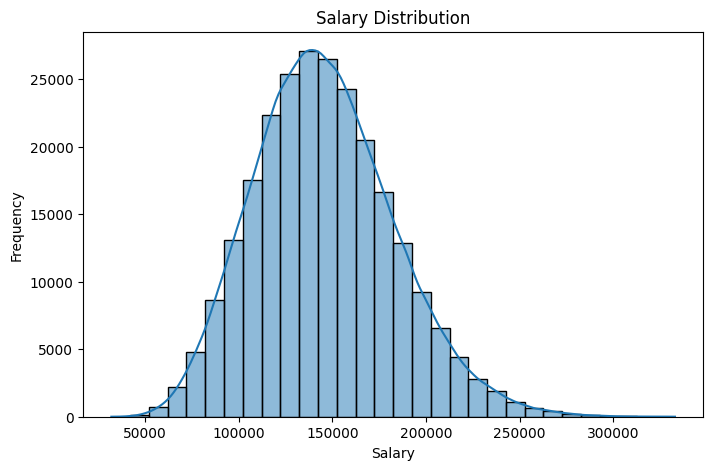

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['salary'], bins=30, kde=True)
# plot histogram of salary distribution
# bins=30: divides the data into 30 intervals
# kde=True: adds a smooth density curve to visualize distribution pattern

plt.title("Salary Distribution")

#x and y axis labeling
plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.show()

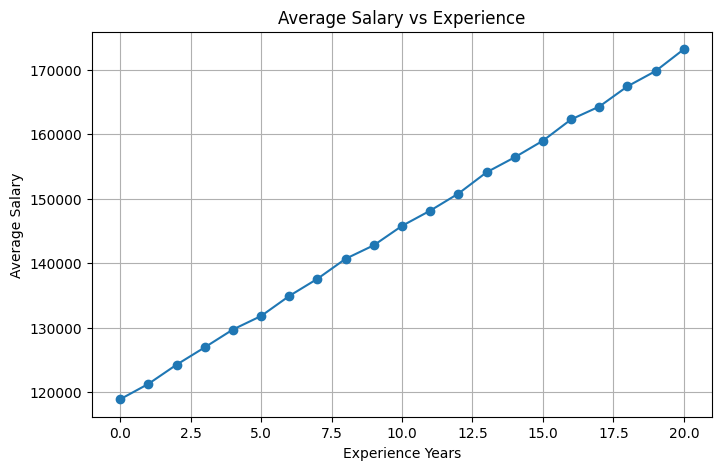

In [ ]:
avg_salary = df.groupby('experience_years')['salary'].mean()
# Calculate average salary for each experience level
# groupby(): groups the data based on experience_years
# mean(): calculates the average salary for each group

plt.figure(figsize=(8,5))

plt.plot(avg_salary.index, avg_salary.values, marker='o') # Plot line graph of average salary against experience years

plt.title("Average Salary vs Experience")

plt.xlabel("Experience Years")

plt.ylabel("Average Salary")

plt.grid(True)

plt.show()

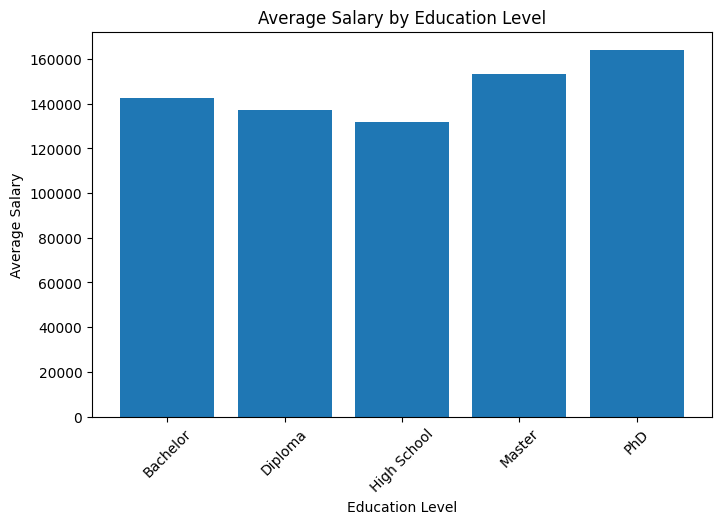

In [ ]:
avg_salary_educ = df.groupby('education_level')['salary'].mean()  # calculating average sallery for each education level

plt.figure(figsize=(8,5))

plt.bar(avg_salary_educ.index, avg_salary_educ.values) #plot Bar graph

plt.title("Average Salary by Education Level")

plt.xlabel("Education Level")

plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

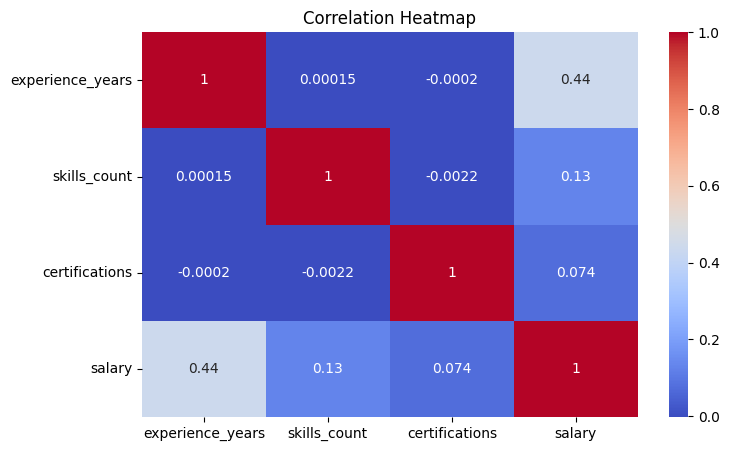

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap( df.corr(numeric_only=True), annot=True, cmap='coolwarm')
# Generate correlation heatmap for numerical variables
# df.corr(): to calculates correlation values between numerical columns
# numeric_only=True: to considers only numerical variables
# annot=True: to displays correlation values inside each cell
# cmap='coolwarm': to sets the color theme of the heatmap

plt.title("Correlation Heatmap")

plt.show()

Separate Features and Target

In [ ]:
# Separate input features and target variable from the dataset

X = df_encoded.drop('salary', axis=1)
# X contains all features
# drop('salary', axis=1): removes the salary column from the dataset

y = df_encoded['salary']
# y contains the target variable that needs to be predicted
# here salary is the output variable

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
# Import train_test_split function from sklearn is used to divide the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train and y_train are used to train the model
# X_test and y_test are used to evaluate model performance
# test_size=0.2 means 20% data is used for testing
# random_state=42 ensures reproducibility of results

Model Training

In [82]:
from sklearn.ensemble import RandomForestRegressor
# Import Random Forest Regressor model from sklearn ensemble module
# Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy

rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Create Random Forest Regression model
# n_estimators=100 means the model will use 100 decision trees

In [78]:
rfr_model.fit(X_train, y_train)
# Train the Random Forest Regression model using training data
# fit() allows the model to learn patterns and relationships between input features (X_train) and target variable (y_train)

RandomForestRegressor(random_state=42)

Prediction

In [79]:
y_pred = rfr_model.predict(X_test)
# Use the trained Random Forest model to make predictions on the testing dataset
# The model predicts salary values based on input features in X_test

Evaluating Performance

In [80]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
# Import evaluation metrics from sklearn
# These metrics are used to measure regression model performance

mae = mean_absolute_error(y_test, y_pred)
# MAE measures the average absolute difference between actual and predicted salary values

mse = mean_squared_error(y_test, y_pred)
# MSE measures the average squared difference between actual and predicted values

r2 = r2_score(y_test, y_pred)
# R2 Score indicates how well the model explains the variance in the target variable
# Higher R2 value means better model performance

# To display Model Performance
print("\nModel Performance:")

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("R2 Score:", r2)


Model Performance:
Mean Absolute Error (MAE): 5693.018592038335
Mean Squared Error (MSE): 54401789.147230245
R2 Score: 0.9608581821826041


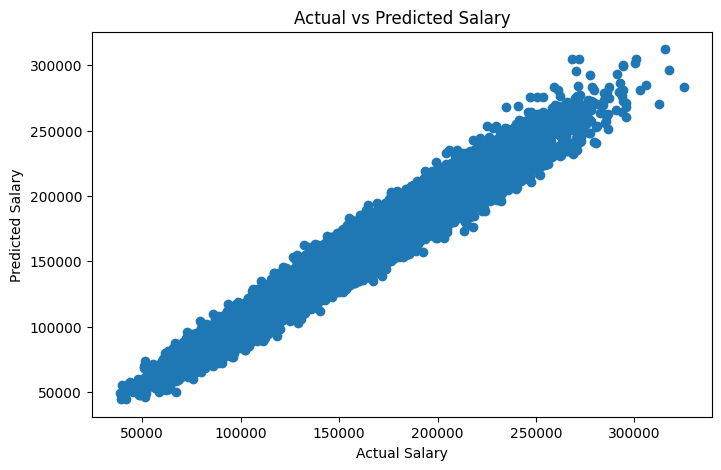

In [81]:
# Visualization: Actual vs Predicted

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)
# Create scatter plot to compare actual salary values with predicted salary values generated by the model

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()